<a href="https://colab.research.google.com/github/Enyaga-Rohan/CATASTROPHE-MODELLING-AND-PRICING-/blob/main/Catasrophe_Modelling%20and%20Pricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install libpysal esda --quiet
import ee
import geemap
import pandas as pd
import numpy as np
import libpysal
from esda.moran import Moran
from scipy.stats import spearmanr
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import folium
import matplotlib.pyplot as plt
from folium.plugins import HeatMap, MarkerCluster
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time
from matplotlib.lines import Line2D
import folium
from geopy.geocoders import Nominatim
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.metrics import (
     average_precision_score,
     brier_score_loss,
     roc_curve,
     precision_recall_curve
)


# INITIALIZE CLOUD COMPUTING SUBSYSTEM
try:
    ee.Initialize(project='nairobi-flooding-ml-model')
except Exception as e:
    print("[INFO]: Secure token missing or expired. Initiating browser authentication...")
    ee.Authenticate()
    ee.Initialize(project='nairobi-flooding-ml-model')


In [ ]:
# GEOGRAPHIC BOUNDING CONSTRAINTS (Nairobi-Kiambu Operational Catchment)
print("[INITIALIZING]: Defining Spatial Region of Interest (ROI)...")
nairobi_kiambu_roi = ee.Geometry.Polygon([
    [36.60, -1.45],  # Southwest anchor
    [37.15, -1.45],  # Southeast anchor
    [37.15, -1.05],  # Northeast anchor
    [36.60, -1.05],  # Northwest anchor
    [36.60, -1.45]   # Closing coordinate ring
])

[INITIALIZING]: Defining Spatial Region of Interest (ROI)...


In [ ]:
# ==============================================================================
# STRUCTURE A: TOPOGRAPHICAL & HYDROLOGICAL DERIVATIVES (NASA SRTM 30m)
# ==============================================================================
print("[PROCESSING]: Sourcing NASA SRTM 30m Digital Elevation Model...")
srtm_source = ee.Image("USGS/SRTMGL1_003")
elevation = srtm_source.clip(nairobi_kiambu_roi).rename("Elevation")

# Calculate derivative terrain metrics natively via Cloud API
slope_deg = ee.Terrain.slope(elevation).rename("Slope")
aspect_deg = ee.Terrain.aspect(elevation).rename("Aspect")

# Compute Curvature via focal neighbor differences (3x3 grid window metric)
mean_focal = elevation.focalMean(radius=30, units="meters")
curvature = elevation.subtract(mean_focal).rename("Curvature")

# Topographic Position Index (TPI): Classifies valleys, slopes, and ridges
tpi = elevation.subtract(elevation.focalMean(radius=300, units="meters")).rename("TPI")



# HYDROLOGICAL DERIVATIVES (Optimized at 30m Resolution via MERIT Hydro)

print("[PROCESSING]: Sourcing MERIT Hydro Flow Accumulation at 30m...")

# 1. Source the 3-arc-second (~90m native but resampled seamlessly to 30m SRTM grid)
# hydro-calibrated dataset. 'uparea' stores upstream drainage area in km²
# THE CORRECT PATH:
merit_hydro = ee.Image("MERIT/Hydro/v1_0_1").clip(nairobi_kiambu_roi)
flow_accum_km2 = merit_hydro.select("upa")     # <-- Changed to "upa"

# 2. Convert square kilometers to square meters to align physical math units
flow_accum = flow_accum_km2.multiply(1000000).rename("Accumulation")

# 3. Match slope units to radians
slope_rad = slope_deg.multiply(np.pi).divide(180)

# 4. Topographic Wetness Index (TWI): ln(α / tan(β))
tan_beta = slope_rad.tan().add(0.001)
twi = flow_accum.divide(tan_beta).max(1.0).log().rename("TWI")

# 5. Stream Power Index (SPI): α × tan(β)
spi = flow_accum.multiply(tan_beta).rename("SPI")

[PROCESSING]: Sourcing NASA SRTM 30m Digital Elevation Model...
[PROCESSING]: Sourcing MERIT Hydro Flow Accumulation at 30m...


In [ ]:
# ==============================================================================
# STRUCTURE B: ECO-SYSTEM & SURFACE IMPERVIOUSNESS LAYERS (SENTINEL-2 SR)
# ==============================================================================
print("[PROCESSING]: Querying Sentinel-2 Surface Reflectance Data Cube...")

def s2_cloud_mask(img):
    """
    Applies strict bitwise clearing filters to isolate valid land reflectance
    metrics from the Sentinel-2 QA band, removing cloud and cirrus noise.
    """
    qa = img.select('QA60')
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11

    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    return img.updateMask(mask)

# Build a cloud-filtered annual image collection for the catchment area
sentinel_collection = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
                       .filterBounds(nairobi_kiambu_roi)
                       .filterDate("2025-01-01", "2025-12-31")
                       .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 5))
                       .map(s2_cloud_mask))

# Generate a clean median mosaic composite and isolate the raw spectral bands
s2_mosaic_raw = sentinel_collection.median().clip(nairobi_kiambu_roi)

# Scale ONLY the optical bands safely by 10,000 to convert to True Surface Reflectance [0, 1]
optical_bands = s2_mosaic_raw.select(['B2', 'B3', 'B4', 'B8', 'B11', 'B12']).divide(10000)

# Derive multi-spectral normalized indicators across the urban-rural gradient
print("   [COMPUTING]: Extracting NDVI, NDBI, and NDWI spectral vectors...")
ndvi = optical_bands.normalizedDifference(["B8", "B4"]).rename("NDVI")   # Vegetation Canopy Shield
ndbi = optical_bands.normalizedDifference(["B11", "B8"]).rename("NDBI")  # Impervious Built-Up/Concrete Cover
ndwi = optical_bands.normalizedDifference(["B3", "B8"]).rename("NDWI")   # Open Water / Surface Saturation Index

# ------------------------------------------------------------------------------
# HYBRID HYDROLOGIC SINK MAPPING ENGINE (CORRECTED TWI THRESHOLD)
# ------------------------------------------------------------------------------
print("   [EXTRACTING]: Fusing structural TWI paths with empirical NDWI water body assets...")

# FIX: Raised from 7.5 to 15.0 so it only captures the highest-accumulation channels
linear_streams = twi.gt(15.0)

# 2. Extract surface water bodies dynamically (Dams, Reservoirs, Wetlands)
surface_water = ndwi.gt(0.15)

# 3. Merge both real-world matrices into a single Joint Hydrologic Sink mask
joint_sink_mask = linear_streams.Or(surface_water)

# 4. Extract SRTM reference variables
srtm_projection = elevation.projection()
srtm_scale = srtm_projection.nominalScale()

# 5. Lock the mask into the 30m grid BEFORE executing the spatial pixel operation
aligned_sink_mask = joint_sink_mask.reproject(crs=srtm_projection, scale=srtm_scale)

# 6. Compute continuous metric distance transform outward
distance_to_stream = (aligned_sink_mask
                      .fastDistanceTransform(neighborhood=256, units="pixels", metric="squared_euclidean")
                      .sqrt()
                      .multiply(srtm_scale)
                      .clip(nairobi_kiambu_roi)
                      .rename("Distance_to_Stream"))

print("✅ [STRUCTURE B COMPLETE]: Proximity layer successfully generated with dynamic variance.")

[PROCESSING]: Querying Sentinel-2 Surface Reflectance Data Cube...
   [COMPUTING]: Extracting NDVI, NDBI, and NDWI spectral vectors...
   [EXTRACTING]: Fusing structural TWI paths with empirical NDWI water body assets...
✅ [STRUCTURE B COMPLETE]: Proximity layer successfully generated with dynamic variance.


In [ ]:
# ==============================================================================
# STRUCTURE C: ATMOSPHERIC FORCING MATRIX (CHIRPS CLIMATOLOGY DAILY)
# ==============================================================================
print("[PROCESSING]: Sourcing CHIRPS High-Resolution Precipitation Arrays...")

#  End date set to 2026-01-01 to ensure December 31st is fully included
chirps_historic = (ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
                   .filterBounds(nairobi_kiambu_roi)
                   .filterDate("2025-01-01", "2026-01-01"))

# Get the native CHIRPS projection from the collection baseline
chirps_projection = ee.Image(chirps_historic.first()).projection()

# Compute baseline precipitation metrics explicitly targeting the rainfall band
rain_total_raw = chirps_historic.select("precipitation").sum()
rain_max_raw = chirps_historic.select("precipitation").max()

# Frequency metric: Apply threshold filter using explicit Earth Engine band selection
def threshold_heavy_rain(img):
    binary_mask = img.select("precipitation").gt(25)
    return binary_mask.copyProperties(img, ["system:time_start"])

rain_heavy_days_raw = chirps_historic.map(threshold_heavy_rain).sum()

# Reference your target 30-meter SRTM geometry
srtm_projection = elevation.projection()
srtm_scale = srtm_projection.nominalScale()

# Corrected Downscaling: Force back to CHIRPS native projection, set resample, then reproject to SRTM
rain_total = (rain_total_raw.setDefaultProjection(chirps_projection)
              .resample("bilinear")
              .reproject(crs=srtm_projection, scale=srtm_scale)
              .rename("Rainfall_Total"))

rain_max = (rain_max_raw.setDefaultProjection(chirps_projection)
             .resample("bilinear")
             .reproject(crs=srtm_projection, scale=srtm_scale)
             .rename("Rainfall_Max_1Day"))

rain_heavy_days = (rain_heavy_days_raw.setDefaultProjection(chirps_projection)
                   .resample("bilinear")
                   .reproject(crs=srtm_projection, scale=srtm_scale)
                   .rename("Rainfall_Heavy_Days"))

print("✅ [STRUCTURE C COMPLETE]: Atmospheric forcing metrics compiled and downscaled successfully.")

[PROCESSING]: Sourcing CHIRPS High-Resolution Precipitation Arrays...
✅ [STRUCTURE C COMPLETE]: Atmospheric forcing metrics compiled and downscaled successfully.


In [ ]:
# ==============================================================================
# STEP 4: MULTI-CHUNK IN-MEMORY CLOUD INGESTION (REVISED)
# ==============================================================================
print("\n" + "="*78)
print(" PRODUCTION ENGINE: STEP 4 — OPTIMIZED STRATIFIED STREAMING")
print("="*78)

# 1. Pull the Empirical Historical Evidence Layer from GEE Data Catalog
print("[EXTRACTION]: Fetching 20-year historical flood footprints vector...")
historical_flood_mask = (ee.Image("JRC/GSW1_4/GlobalSurfaceWater")
                         .select("recurrence")
                         .gt(10)
                         .unmask(0)
                         .clip(nairobi_kiambu_roi)
                         .rename("Historical_Flood_Occurred"))

# 2. Inject explicit geographical coordinate layers into the raster context
print("[PATCH]: Injecting explicit coordinate layers into the raster stack...")
lon_lat_bands = ee.Image.pixelLonLat().clip(nairobi_kiambu_roi).rename(["Longitude", "Latitude"])

# 3. Bind all multi-spectral, terrain, meteorological, and target arrays
print("[STACKING]: Binding all 17 spatial layers + Historical Evidence to 30m grid...")
comprehensive_spatial_stack = elevation.addBands([
    slope_deg, aspect_deg, curvature, tpi, twi, spi,  # Terrain Geometry
    distance_to_stream, ndvi, ndbi, ndwi,             # Spectral Indices
    rain_total, rain_max, rain_heavy_days,            # Climate Matrices
    historical_flood_mask,                            # Core Empirical Validation Target
    lon_lat_bands                                     # Geospatial Coordinates
])

# ---- SPEED, STABILITY, & GRID ALIGNMENT CORRECTIONS ----
# Pull the native projection reference profile from the base SRTM asset
srtm_projection = elevation.projection()

# Explicitly bound the stack to your target area. This prevents back-tracing
# complex variables (like distance transforms) outside your study region.
bounded_spatial_stack = comprehensive_spatial_stack.clip(nairobi_kiambu_roi)

# 4. Run server-side STRATIFIED sampling passing the target projection explicitly
print("[SAMPLING]: Requesting server-side balanced stratified extraction (5,000 flooded vs 5,000 dry)...")
stratified_samples = bounded_spatial_stack.stratifiedSample(
    numPoints=5000,
    classBand="Historical_Flood_Occurred",
    region=nairobi_kiambu_roi,
    projection=srtm_projection, # Align pixel extraction directly to the SRTM grid mesh
    seed=777,
    geometries=False
)

# 5. Export directly as a compressed server-side CSV stream to bypass JSON overhead caps
print("[STREAMING]: Requesting high-performance compressed data stream from GEE...")
download_url = stratified_samples.getDownloadURL(
    filetype="CSV",
    selectors=[
        "Elevation", "Slope", "Aspect", "Curvature", "TPI", "TWI", "SPI",
        "Distance_to_Stream", "NDVI", "NDBI", "NDWI",
        "Rainfall_Total", "Rainfall_Max_1Day", "Rainfall_Heavy_Days",
        "Longitude", "Latitude", "Historical_Flood_Occurred"
    ]
)

# 6. Parse stream directly into working Pandas DataFrame context
print("[PARSING]: Ingesting compressed stream into unified Pandas matrix...")
df = pd.read_csv(download_url)

print("-"*78)
print("✅ [PIPELINE SUCCESS]: Active workspace DataFrame successfully initialized!")
print(f"    -> Retained Shape: {df.shape[0]} matrix rows, {df.shape[1]} balanced feature columns.")
print("="*78 + "\n")


 PRODUCTION ENGINE: STEP 4 — OPTIMIZED STRATIFIED STREAMING
[EXTRACTION]: Fetching 20-year historical flood footprints vector...
[PATCH]: Injecting explicit coordinate layers into the raster stack...
[STACKING]: Binding all 17 spatial layers + Historical Evidence to 30m grid...
[SAMPLING]: Requesting server-side balanced stratified extraction (5,000 flooded vs 5,000 dry)...
[STREAMING]: Requesting high-performance compressed data stream from GEE...
[PARSING]: Ingesting compressed stream into unified Pandas matrix...
------------------------------------------------------------------------------
✅ [PIPELINE SUCCESS]: Active workspace DataFrame successfully initialized!
    -> Retained Shape: 10000 matrix rows, 17 balanced feature columns.



In [ ]:
print(list(df.columns))

['Elevation', 'Slope', 'Aspect', 'Curvature', 'TPI', 'TWI', 'SPI', 'Distance_to_Stream', 'NDVI', 'NDBI', 'NDWI', 'Rainfall_Total', 'Rainfall_Max_1Day', 'Rainfall_Heavy_Days', 'Longitude', 'Latitude', 'Historical_Flood_Occurred']


In [ ]:
print("\n" + "="*78)
print(" PRODUCTION ENGINE: DATAFRAME VARIANCE AUDIT")
print("="*78)

# 1. Calculate raw variance for every numeric column
raw_variance = df.var(numeric_only=True)

# 2. Print a scannable table of standard deviations and ranges
print(f"{'Column Name':<30} | {'Std Dev (s)':<12} | {'Min':<10} | {'Max':<10}")
print("-" * 78)

for col in df.select_dtypes(include=['number']).columns:
    col_std = df[col].std()
    col_min = df[col].min()
    col_max = df[col].max()
    print(f"{col:<30} | {col_std:<12.4f} | {col_min:<10.4f} | {col_max:<10.4f}")

print("="*78 + "\n")


 PRODUCTION ENGINE: DATAFRAME VARIANCE AUDIT
Column Name                    | Std Dev (s)  | Min        | Max       
------------------------------------------------------------------------------
Elevation                      | 201.1906     | 1422.0000  | 2418.0000 
Slope                          | 4.0023       | 0.0000     | 34.5619   
Aspect                         | 110.7932     | -0.0000    | 357.6137  
Curvature                      | 0.0000       | 0.0000     | 0.0000    
TPI                            | 5.6478       | -38.1160   | 52.3379   
TWI                            | 3.2491       | 9.5060     | 26.3360   
SPI                            | 14187703.8020 | 8.5452     | 1024731450.2039
Distance_to_Stream             | 63.5887      | 0.0000     | 928.1776  
NDVI                           | 0.2899       | -0.5585    | 0.9026    
NDBI                           | 0.2287       | -0.7258    | 0.4136    
NDWI                           | 0.3118       | -0.8561    | 0.5857    
Rainf

In [ ]:
# ==============================================================================
# PRODUCTION ENGINE: PHASE 2 — STABLE AHP VECTOR FUSION
# ENVIRONMENT: Python 3.x (Native Data Stack)
# PROTECTION: Enforces Epsilon Stabilizers & Pre-Fusion Vector Cleansing
# ==============================================================================

print("\n" + "="*78)
print(" PRODUCTION ENGINE: PHASE 2 — STABLE AHP VECTOR FUSION")
print("="*78)

# ------------------------------------------------------------------------------
# STEP 1: IN-MEMORY DATA EXTRACTION & WORKSPACE VALIDATION
# ------------------------------------------------------------------------------
print("[LOAD CHECK]: Verifying active in-memory spatial dataframe from Step 4...")
if 'df' not in locals() and 'df' not in globals():
    raise NameError("❌ Active workspace 'df' not found. Please execute the Step 4 Streaming cell first.")

print(f"   -> Found active matrix with {df.shape[0]} valid observations from GEE.")

# 1. DATA CLEANSING GATES: Handle any missing observations natively
print("[CLEANSING]: Aligning variable structures and checking missing inputs...")
# Safely isolate the classification target before applying uniform data corrections
target_col = "Historical_Flood_Occurred"
cols_to_numeric = [col for col in df.columns if col not in ["Longitude", "Latitude", target_col]]

df[cols_to_numeric] = df[cols_to_numeric].apply(pd.to_numeric, errors='coerce')
df[cols_to_numeric] = df[cols_to_numeric].fillna(df[cols_to_numeric].median())

# Define explicit 14-layer environmental framework array (Casing Aligned exactly to GEE output)
layers = [
    "TWI", "NDBI", "Rainfall_Max_1Day", "Distance_to_Stream", "Elevation",
    "Slope", "SPI", "Rainfall_Heavy_Days", "NDWI", "Curvature",
    "TPI", "Rainfall_Total", "NDVI", "Aspect"
]
n = len(layers)

# Pre-flight structural sanity check to protect matrix multiplication
missing_layers = [layer for layer in layers if layer not in df.columns]
if missing_layers:
    raise KeyError(f"❌ Execution Halted: Missing required bands in df workspace: {missing_layers}")
print("✅ [PRE-FLIGHT]: All 14 physical environmental layers successfully mapped.")

# ------------------------------------------------------------------------------
# STEP 2: PAIRWISE ESTIMATION MATRICES (AHP WEIGHT DERIVATION)
# ------------------------------------------------------------------------------
print("[PROCESSING]: Synthesizing Analytical Hierarchy Process weight vectors...")

# Initialize identity pairwise matrix
AHP_Matrix = np.ones((n, n))

# Mathematical priorities dict based on exact column names
weights_dict = {
    "TWI": 0.22, "NDBI": 0.18, "Rainfall_Max_1Day": 0.14, "Distance_to_Stream": 0.12,
    "Elevation": 0.08, "Slope": 0.06, "SPI": 0.05, "Rainfall_Heavy_Days": 0.04,
    "NDWI": 0.04, "Curvature": 0.02, "TPI": 0.02, "Rainfall_Total": 0.01,
    "NDVI": 0.01, "Aspect": 0.01
}

# Construct perfectly consistent reciprocal balances
for i in range(n):
    for j in range(n):
        AHP_Matrix[i, j] = weights_dict[layers[i]] / weights_dict[layers[j]]

# Eigenvalue calculation via column normalization approximation
column_sums = AHP_Matrix.sum(axis=0)
normalized_matrix = AHP_Matrix / column_sums
ahp_weights = normalized_matrix.mean(axis=1)

print("   -> Derived Analytical Weight Vectors successfully compiled:")
for layer, weight in zip(layers, ahp_weights):
    print(f"      * {layer:<22} Assigned Structural Weight: {weight:.4f}")

# ------------------------------------------------------------------------------
# STEP 3: FEATURE MATRIX NORMALIZATION AND VECTOR DOT-PRODUCT
# ------------------------------------------------------------------------------
print("[COMPUTING]: Scaling physical gradients into uniform [0, 1] risk bounds...")

df_scaled = pd.DataFrame(index=df.index)
eps = 1e-7  # Numerical buffer protecting against division-by-zero errors

for layer in layers:
    min_val = df[layer].min()
    max_val = df[layer].max()

    # Special Handling for Aspect: Treat negative values (flat land) as neutral risk (0.5)
    if layer == "Aspect":
        # Neutralize default flat values (-1 or 0) and minimize circular angular error
        df_scaled[layer] = df[layer].apply(lambda x: 0.5 if x < 0 else (x / 360.0))
    elif layer in ["Elevation", "Distance_to_Stream"]:
        # Invert scale for parameters where higher metrics reduce flood risk
        df_scaled[layer] = (max_val - df[layer]) / (max_val - min_val + eps)
    else:
        # Standard directional risk scale (Higher value = Higher risk)
        df_scaled[layer] = (df[layer] - min_val) / (max_val - min_val + eps)

print("[FUSION]: Executing structural linear vector dot-product...")
# Map the dot product directly to create the final FSI Baseline vector
df["FSI_Baseline"] = df_scaled[layers].dot(ahp_weights)
df["FSI_Baseline"] = df["FSI_Baseline"].clip(0.0, 1.0)

print("-"*78)
print("✅ [PHASE 2 COMPLETE]: Spatial baseline vector fused perfectly into memory workspace.")
print(f"   -> FSI Baseline Metrics: Mean: {df['FSI_Baseline'].mean():.4f} | StdDev: {df['FSI_Baseline'].std():.4f}")
print("="*78 + "\n")


 PRODUCTION ENGINE: PHASE 2 — STABLE AHP VECTOR FUSION
[LOAD CHECK]: Verifying active in-memory spatial dataframe from Step 4...
   -> Found active matrix with 10000 valid observations from GEE.
[CLEANSING]: Aligning variable structures and checking missing inputs...
✅ [PRE-FLIGHT]: All 14 physical environmental layers successfully mapped.
[PROCESSING]: Synthesizing Analytical Hierarchy Process weight vectors...
   -> Derived Analytical Weight Vectors successfully compiled:
      * TWI                    Assigned Structural Weight: 0.2200
      * NDBI                   Assigned Structural Weight: 0.1800
      * Rainfall_Max_1Day      Assigned Structural Weight: 0.1400
      * Distance_to_Stream     Assigned Structural Weight: 0.1200
      * Elevation              Assigned Structural Weight: 0.0800
      * Slope                  Assigned Structural Weight: 0.0600
      * SPI                    Assigned Structural Weight: 0.0500
      * Rainfall_Heavy_Days    Assigned Structural Weight:

In [ ]:
print("\n" + "="*78)
print(" PRODUCTION ENGINE: STEP 1 — SPATIAL AUTOCORRELATION DIAGNOSTICS")
print("="*78)
print("[DIAGNOSTIC]: Initializing Spatial Coordinate Network...")

# Extract coordinates and our newly generated target vector
coords = df[["Longitude", "Latitude"]].values
target_vector = df["FSI_Baseline"].values

# Construct a Spatial K-Nearest Neighbors weight matrix (k = 8 surrounding cell anchors)
print("[COMPUTING]: Generating Spatial Weights Matrix (k=8)...")
spatial_knn = libpysal.weights.KNN.from_array(coords, k=8)
spatial_knn.transform = 'R'  # Row-standardize weights to neutralize scale variance

print("[COMPUTING]: Executing Global Moran's I Stochastic Test...")
# FIXED: Called the explicitly imported Moran class from the esda library
moran_engine = Moran(target_vector, spatial_knn)

print(f"   -> Observed Moran's I Statistic : {moran_engine.I:.4f}")
print(f"   -> Expected Random Distribution : {moran_engine.EI:.4f}")
print(f"   -> Simulated P-Value Probability: {moran_engine.p_sim:.6f}")

print("-"*78)
# Automated fail-safe check for geographical continuity
if moran_engine.p_sim > 0.05:
    print("⚠️ WARNING: Weak spatial dependency structure detected. Review bounding coordinates.")
else:
    print("✅ [SPATIAL INTEGRITY PASSED]: Catchments exhibit highly deterministic geographic clustering.")
print("="*78 + "\n")


 PRODUCTION ENGINE: STEP 1 — SPATIAL AUTOCORRELATION DIAGNOSTICS
[DIAGNOSTIC]: Initializing Spatial Coordinate Network...
[COMPUTING]: Generating Spatial Weights Matrix (k=8)...
[COMPUTING]: Executing Global Moran's I Stochastic Test...
   -> Observed Moran's I Statistic : 0.4862
   -> Expected Random Distribution : -0.0001
   -> Simulated P-Value Probability: 0.001000
------------------------------------------------------------------------------
✅ [SPATIAL INTEGRITY PASSED]: Catchments exhibit highly deterministic geographic clustering.



In [ ]:
print("\n" + "="*78)
print(" PRODUCTION ENGINE: STEP 2 — PHYSICAL SANITY & MONOTONICITY STRESS-TEST")
print("="*78)
print("[DIAGNOSTIC]: Evaluating Physical Monotonicity Vectors (Spearman Rank)...")

# Verify calculations align with regional geographic realities
elevation_corr, _ = spearmanr(df["FSI_Baseline"], df["Elevation"])
stream_dist_corr, _ = spearmanr(df["FSI_Baseline"], df["Distance_to_Stream"])
urban_density_corr, _ = spearmanr(df["FSI_Baseline"], df["NDBI"])

print(f"   -> Spearman Rho [FSI vs Elevation]         : {elevation_corr:.4f}")
print("      (Regional Trend: Often positive/neutral due to high-altitude Aberdare rainfall runoff)")
print(f"   -> Spearman Rho [FSI vs Distance to Stream]: {stream_dist_corr:.4f}")
print("      (Target: Strictly Negative — Risk must scale up as distance decreases)")
print(f"   -> Spearman Rho [FSI vs Urban NDBI Cover]  : {urban_density_corr:.4f}")
print("      (Regional Trend: Frequently negative due to ridge-sited urban business zones)")

print("-"*78)
# ─────────────── HARDENED INSTITUTIONAL VALIDATION GATES ───────────────
# Enforce strict validation based on non-negotiable hydraulic physics (Stream Proximity)
if stream_dist_corr >= 0:
    raise ValueError("❌ Hydraulic Contradiction! Risk decreases closer to streams. Pipeline broken.")

print("✅ [PHYSICAL MONOTONICITY PASSED]: Target metrics adhere strictly to East African catchment realities.")
print("="*78 + "\n")


 PRODUCTION ENGINE: STEP 2 — PHYSICAL SANITY & MONOTONICITY STRESS-TEST
[DIAGNOSTIC]: Evaluating Physical Monotonicity Vectors (Spearman Rank)...
   -> Spearman Rho [FSI vs Elevation]         : -0.0030
      (Regional Trend: Often positive/neutral due to high-altitude Aberdare rainfall runoff)
   -> Spearman Rho [FSI vs Distance to Stream]: -0.4756
      (Target: Strictly Negative — Risk must scale up as distance decreases)
   -> Spearman Rho [FSI vs Urban NDBI Cover]  : 0.4043
      (Regional Trend: Frequently negative due to ridge-sited urban business zones)
------------------------------------------------------------------------------
✅ [PHYSICAL MONOTONICITY PASSED]: Target metrics adhere strictly to East African catchment realities.



In [ ]:
# ==============================================================================
# STEP 3: CONTRAST THRESHOLD FILTERING & OUTLIER REMOVAL
# ENVIRONMENT: Python 3.x (In-Memory Signal Processing)
# PROTECTION: Enforces 3-Sigma Gaussian Bounds to Prune Edge Anomalies
# ==============================================================================


print("\n" + "="*78)
print(" PRODUCTION ENGINE: STEP 3 — CONTRAST THRESHOLD FILTERING")
print("="*78)
print("[FILTERING]: Trimming mathematical edge-case anomalies...")

# Calculate distribution parameters across the continuous baseline score
fsi_mean = df["FSI_Baseline"].mean()
fsi_std = df["FSI_Baseline"].std()

# Define structural 3-Standard-Deviation operational boundaries
lower_bound = fsi_mean - (3 * fsi_std)
upper_bound = fsi_mean + (3 * fsi_std)

print(f"   -> Calculated Statistical Mean  : {fsi_mean:.4f}")
print(f"   -> Calculated Standard Deviation: {fsi_std:.4f}")
print(f"   -> Active Filter Threshold Slice : [{lower_bound:.4f} to {upper_bound:.4f}]")

# Record row-count prior to filtering execution
initial_rows = len(df)

# Execute in-memory truncation, maintaining df as the master reference variable
df = df[(df["FSI_Baseline"] >= lower_bound) & (df["FSI_Baseline"] <= upper_bound)].copy()

removed_rows = initial_rows - len(df)
print(f"   -> Successfully pruned {removed_rows} anomalous micro-noise pixels from data pool.")
print(f"   -> Active workspace matrix stabilized at {df.shape[0]} valid observations.")

print("-"*78)
print("✅ [PHASE 3 VALIDATION COMPLETE]: Matrix filtered and synchronized in active memory.")
print("="*78 + "\n")


 PRODUCTION ENGINE: STEP 3 — CONTRAST THRESHOLD FILTERING
[FILTERING]: Trimming mathematical edge-case anomalies...
   -> Calculated Statistical Mean  : 0.4551
   -> Calculated Standard Deviation: 0.0525
   -> Active Filter Threshold Slice : [0.2978 to 0.6125]
   -> Successfully pruned 13 anomalous micro-noise pixels from data pool.
   -> Active workspace matrix stabilized at 9987 valid observations.
------------------------------------------------------------------------------
✅ [PHASE 3 VALIDATION COMPLETE]: Matrix filtered and synchronized in active memory.



In [ ]:
# ==============================================================================
# PRODUCTION ENGINE: PHASE 4 — SUPERVISED BINARY CLASSIFICATION & EMPIRICAL PROBABILITY
# ENVIRONMENT: Python 3.x (LightGBM Classification Stack)
# PROTECTION: Direct Ground-Truth Training with AHP Domain Feature Integration
# ==============================================================================

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, log_loss

print("\n" + "="*78)
print(" PRODUCTION ENGINE: PHASE 4 — SUPERVISED EMPIRICAL FLOOD MODELING")
print("="*78)
print("[LOADING]: Sourcing Phase 3 Validated In-Memory Environmental Master Dataset...")

# Ensure reference safety across variables
if 'df' not in locals() and 'df' not in globals():
    raise NameError("❌ Active workspace 'df' not found in RAM context. Please rerun Step 3.")

# ==============================================================================
# STEP 1: SEGREGATE FEATURES AND TARGET VECTOR
# ==============================================================================
# CRITICAL PIVOT: Keep FSI_Baseline in X (feature_cols) as an AHP expert prior.
# Only drop spatial coordinates, metadata, and true ground truth targets.
drop_cols = [
    "Longitude", "Latitude", "system:index", ".geo",
    "Historical_Flood_Occurred", "Expected_Annual_Loss_KES",
    "Predicted_FSI_Median", "Predicted_FSI_Tail_Extreme",
    "Predicted_Flood_Probability", "Curvature"
]
feature_cols = [col for col in df.columns if col not in drop_cols]

# Spatial Block Partition via median Longitude pivot to eliminate coordinate target leakage
spatial_pivot = df["Longitude"].median()
train_mask = df["Longitude"] <= spatial_pivot
val_mask = df["Longitude"] > spatial_pivot

X_train = df.loc[train_mask, feature_cols]
y_train = df.loc[train_mask, "Historical_Flood_Occurred"].astype(int)

X_val = df.loc[val_mask, feature_cols]
y_val = df.loc[val_mask, "Historical_Flood_Occurred"].astype(int)

print(f" ✅ [DE-LEAKED SPATIAL PARTITION]: Split cleanly on Longitude Pivot Axis: {spatial_pivot:.4f}")
print(f"   -> Training Feature Matrix Shape (West Block) : {X_train.shape}")
print(f"   -> Validation Matrix Target Shape (East Block): {X_val.shape}")
print(f"   -> Retained Features (Including AHP Prior)   :\n      {list(feature_cols)}")

# ==============================================================================
# STEP 2: TRAIN LIGHTGBM BINARY CLASSIFIER
# ==============================================================================
print("\n[OPTIMIZING]: Initializing LightGBM Binary Classification Framework...")

lgb_params = {
    'boosting_type': 'gbdt',
    'objective': 'binary',               # Switched from quantile regression to binary classification
    'metric': 'binary_logloss',
    'n_estimators': 300,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 777,
    'n_jobs': -1,
    'verbose': -1,
    'importance_type': 'gain'            # Measures actual mathematical contribution to loss reduction
}

# Train Empirical Classifier on Historical Ground Truth
print("   [TRAINING]: Fitting Gradient Boosted Decision Trees on Historical_Flood_Occurred...")
model_lgb = lgb.LGBMClassifier(**lgb_params)
model_lgb.fit(X_train, y_train)

# ==============================================================================
# STEP 3: OUT-OF-SAMPLE PERFORMANCE EVALUATION & WORKSPACE SYNC
# ==============================================================================
print("\n[EVALUATING]: Generating Spatial Out-of-Sample Probability Predictions...")
val_probs = model_lgb.predict_proba(X_val)[:, 1]

val_auc = roc_auc_score(y_val, val_probs)
val_loss = log_loss(y_val, val_probs)

print(f"   -> Spatial Val Model Out-of-Sample Log-Loss : {val_loss:.5f}")
print(f"   -> Spatial Val Model Honest ROC-AUC Score  : {val_auc:.4f}")

# Infer continuous empirical flood probability [0.0, 1.0] across all spatial points
X_all_points = df[feature_cols]
full_probs = model_lgb.predict_proba(X_all_points)[:, 1]

# Store full probability map and synchronize with downstream pipeline references
df["Predicted_Flood_Probability"] = full_probs
df["Predicted_FSI_Median"] = full_probs
df["Predicted_FSI_Tail_Extreme"] = full_probs

# ==============================================================================
# STEP 4: MACHINE LEARNING FEATURE IMPORTANCE EXTRACTION
# ==============================================================================
print("\n" + "-"*78)
print("--- Non-Linear Feature Importance Ranking (Total Information Gain) ---")
print("-"*78)
importance_df = pd.DataFrame({
    "Environmental_Feature": feature_cols,
    "Information_Gain": model_lgb.feature_importances_
}).sort_values(by="Information_Gain", ascending=False)

for idx, row in importance_df.iterrows():
    print(f"   * {row['Environmental_Feature']:<25}: {row['Information_Gain']:.2f} total gain")
print("="*78 + "\n")


 PRODUCTION ENGINE: PHASE 4 — SUPERVISED EMPIRICAL FLOOD MODELING
[LOADING]: Sourcing Phase 3 Validated In-Memory Environmental Master Dataset...
 ✅ [DE-LEAKED SPATIAL PARTITION]: Split cleanly on Longitude Pivot Axis: 36.9381
   -> Training Feature Matrix Shape (West Block) : (4998, 17)
   -> Validation Matrix Target Shape (East Block): (4989, 17)
   -> Retained Features (Including AHP Prior)   :
      ['Elevation', 'Slope', 'Aspect', 'TPI', 'TWI', 'SPI', 'Distance_to_Stream', 'NDVI', 'NDBI', 'NDWI', 'Rainfall_Total', 'Rainfall_Max_1Day', 'Rainfall_Heavy_Days', 'FSI_Baseline', 'Hazard_Class', 'True_Asset_Density', 'Expected_Loss_Index']

[OPTIMIZING]: Initializing LightGBM Binary Classification Framework...
   [TRAINING]: Fitting Gradient Boosted Decision Trees on Historical_Flood_Occurred...

[EVALUATING]: Generating Spatial Out-of-Sample Probability Predictions...
   -> Spatial Val Model Out-of-Sample Log-Loss : 0.34486
   -> Spatial Val Model Honest ROC-AUC Score  : 0.9359

------

In [ ]:
# ==============================================================================
# PRODUCTION ENGINE: PHASE 5 — CATASTROPHE VULNERABILITY SCALING (ABSOLUTE TIERS)
# ENVIRONMENT: Python 3.x (Actuarial Hazard Stratification Layer)
# PROTECTION: Absolute Empirical Probability Thresholds for Risk Underwriting
# ==============================================================================


print("\n" + "="*78)
print(" PRODUCTION ENGINE: PHASE 5 — CATASTROPHE VULNERABILITY SCALING")
print("="*78)
print("[LOADING]: Sourcing Phase 4 Predictive Machine Learning Probability Matrices...")

if 'df' not in locals() and 'df' not in globals():
    raise NameError("❌ Active workspace 'df' not found in RAM context. Please execute Phase 4 first.")

# ==============================================================================
# STEP 1: ABSOLUTE PROBABILITY STRATIFICATION (ACTUARIAL HAZARD BANDS)
# ==============================================================================
print("[SCALING]: Stratifying spatial grid points into absolute empirical probability bounds...")

# Define standard physical risk thresholds:
# Low: < 25% | Moderate: 25% - 60% | High: 60% - 85% | Extreme Tail: > 85%
bins = [-np.inf, 0.25, 0.60, 0.85, np.inf]
labels = ["Low_Hazard", "Moderate_Hazard", "High_Hazard", "Extreme_Tail_Hazard"]

df["Hazard_Class"] = pd.cut(df["Predicted_Flood_Probability"], bins=bins, labels=labels)

# Display active actuarial boundaries
print("\n🔍 Actuarial Absolute Hazard Boundary Distribution:")
print("   -> Low Range       : Probabilities < 0.2500 (< 25% Risk)")
print("   -> Moderate Range  : Probabilities [0.2500 to 0.6000] (25% - 60% Risk)")
print("   -> High Range      : Probabilities [0.6000 to 0.8500] (60% - 85% Risk)")
print("   -> Extreme Tail    : Probabilities > 0.8500 (> 85% Extreme Risk)")

# Generate diagnostic breakdown of pixel allocation across physical bands
counts = df["Hazard_Class"].value_counts(sort=False)
percentages = (df["Hazard_Class"].value_counts(normalize=True, sort=False) * 100)

print("-" * 78)
print("Spatial Allocation Across Catastrophe Hazard Bands:")
for label in labels:
    print(f"   * {label:<22}: {counts[label]:>5} pixels ({percentages[label]:>6.2f}%)")

print("-" * 78)
print("✅ [HAZARD BANDS STABILIZED]: Physical probability bounds aligned for actuarial pricing.")
print("="*78 + "\n")


 PRODUCTION ENGINE: PHASE 5 — CATASTROPHE VULNERABILITY SCALING
[LOADING]: Sourcing Phase 4 Predictive Machine Learning Probability Matrices...
[SCALING]: Stratifying spatial grid points into absolute empirical probability bounds...

🔍 Actuarial Absolute Hazard Boundary Distribution:
   -> Low Range       : Probabilities < 0.2500 (< 25% Risk)
   -> Moderate Range  : Probabilities [0.2500 to 0.6000] (25% - 60% Risk)
   -> High Range      : Probabilities [0.6000 to 0.8500] (60% - 85% Risk)
   -> Extreme Tail    : Probabilities > 0.8500 (> 85% Extreme Risk)
------------------------------------------------------------------------------
Spatial Allocation Across Catastrophe Hazard Bands:
   * Low_Hazard            :  4890 pixels ( 48.96%)
   * Moderate_Hazard       :   581 pixels (  5.82%)
   * High_Hazard           :   518 pixels (  5.19%)
   * Extreme_Tail_Hazard   :  3998 pixels ( 40.03%)
------------------------------------------------------------------------------
✅ [HAZARD BANDS STAB

In [ ]:
# ==============================================================================
# PRODUCTION ENGINE: STEP 2 — FINANCIAL VULNERABILITY FUSION (ELI)
# ENVIRONMENT: Python 3.x (Actuarial Quantitative Risk Modeling)
# PROTECTION: Strict Clipping and Zero-Masking for Non-Asset Surfaces
# ==============================================================================

import numpy as np
import pandas as pd

print("\n" + "="*78)
print(" PRODUCTION ENGINE: STEP 2 — FINANCIAL VULNERABILITY FUSION (ELI)")
print("="*78)
print("[UNDERWRITING]: Synthesizing infrastructure vulnerability loss function...")

if 'df' not in locals() and 'df' not in globals():
    raise NameError("❌ Active workspace 'df' not found in RAM context. Please execute previous phases first.")

# 1. Isolate true built infrastructure. Only NDBI > 0 represents concrete/structures.
df["True_Asset_Density"] = df["NDBI"].clip(lower=0.0)

# 2. Min-Max normalize asset density across built surfaces
eps = 1e-7
asset_min = df["True_Asset_Density"].min()
asset_max = df["True_Asset_Density"].max()
normalized_asset = (df["True_Asset_Density"] - asset_min) / ((asset_max - asset_min) + eps)

# 3. Reference continuous empirical flood probability [0.0 to 1.0]
clamped_risk = df["Predicted_Flood_Probability"].clip(lower=0.0, upper=1.0)

# 4. Compute Expected Loss Index (ELI = P(Flood)^2 * Asset_Density)
df["Expected_Loss_Index"] = (clamped_risk ** 2) * normalized_asset

# 5. Financial exposure translation (if base asset valuation is present)
if "Expected_Annual_Loss_KES" in df.columns:
    df["Financial_Loss_Exposure_KES"] = df["Expected_Loss_Index"] * df["Expected_Annual_Loss_KES"]
    has_financials = True
else:
    has_financials = False

# Print spatial diagnostics
print(f" ✅ [UNDERWRITING BOUNDS ENFORCED]: Cleared non-built surfaces from asset pool.")
print(f"   -> Mean Portfolio ELI Value        : {df['Expected_Loss_Index'].mean():.5f}")
print(f"   -> Peak Maximum ELI Exposure Value : {df['Expected_Loss_Index'].max():.5f}")

if has_financials:
    print(f"   -> Total Portfolio Risk Exposure   : KES {df['Financial_Loss_Exposure_KES'].sum():,.2f}")
    print(f"   -> Maximum Single Pixel Loss Risk  : KES {df['Financial_Loss_Exposure_KES'].max():,.2f}")

print("-" * 78)
print("✅ [FINANCIAL FUSION COMPLETE]: Active RAM dataset optimized for ILS structure injections.")
print("="*78 + "\n")


 PRODUCTION ENGINE: STEP 2 — FINANCIAL VULNERABILITY FUSION (ELI)
[UNDERWRITING]: Synthesizing infrastructure vulnerability loss function...
 ✅ [UNDERWRITING BOUNDS ENFORCED]: Cleared non-built surfaces from asset pool.
   -> Mean Portfolio ELI Value        : 0.02764
   -> Peak Maximum ELI Exposure Value : 0.86569
------------------------------------------------------------------------------
✅ [FINANCIAL FUSION COMPLETE]: Active RAM dataset optimized for ILS structure injections.



In [ ]:
# ==============================================================================
# STEP 3: EXECUTIVE ADMINISTRATIVE EXPOSURE PROFILE SUMMARY (PHYSICAL RESILIENCE)
# ENVIRONMENT: Python 3.x (Executive Reporting & Actuarial Summary Layer)
# PROTECTION: Stream-Linked Active RAM Data Parsing — Pure Relative Risk Analytics
# ==============================================================================

print("\n" + "="*78)
print("       EXECUTIVE RISK EXPOSURE PROFILE: NAIROBI-KIAMBU RISK CONCENTRATION")
print("="*78)

if 'df' not in locals() and 'df' not in globals():
    raise NameError("❌ Active workspace 'df' not found in RAM context. Please execute previous phases first.")

# 1. Extract structural allocation counts and relative index aggregations
class_counts = df["Hazard_Class"].value_counts()
class_percentages = df["Hazard_Class"].value_counts(normalize=True) * 100

# Aggregate the Expected Loss Index across the zones to locate risk concentrations
zone_risk_impact = df.groupby("Hazard_Class", observed=False)["Expected_Loss_Index"].sum()
total_portfolio_risk = zone_risk_impact.sum()

total_pixels = len(df)
total_area_sqkm = total_pixels * (30 * 30) / 1_000_000  # Converts 30m pixels to square kilometers

print(f" 📈 PORTFOLIO METRICS SUMMARY:")
print(f"    * Total Assessed Land Area       : {total_area_sqkm:,.2f} km²")
print(f"    * Total Grid Points (30m Res)    : {total_pixels:,} pixels")
print("-" * 78)

# 2. Print the Physical Footprint vs. Relative Risk Concentration Table
print(f"{'HAZARD PROFILE TIER':<22} | {'LAND FOOTPRINT':<20} | {'RELATIVE RISK WEIGHT SHARE'}")
print("-" * 78)

labels = ["Low_Hazard", "Moderate_Hazard", "High_Hazard", "Extreme_Tail_Hazard"]
for label in labels:
    cnt = class_counts.get(label, 0)
    pct = class_percentages.get(label, 0.0)
    zone_risk = zone_risk_impact.get(label, 0.0)
    zone_share = (zone_risk / total_portfolio_risk) * 100 if total_portfolio_risk > 0 else 0.0

    # Format categories neatly for presentation
    clean_label = label.replace("_", " ").title()
    footprint_str = f"{cnt:<6} pixels ({pct:>5.1f}%)"
    risk_share_str = f"{zone_share:>5.1f}% of total index weight"

    print(f"{clean_label:<22} | {footprint_str:<20} | {risk_share_str}")

print("-" * 78)

# 3. Generate the Actionable C-Suite Core Takeaway Narrative
extreme_pct = class_percentages.get("Extreme_Tail_Hazard", 0.0)
extreme_share = (zone_risk_impact.get("Extreme_Tail_Hazard", 0.0) / total_portfolio_risk) * 100 if total_portfolio_risk > 0 else 0.0
risk_leverage_ratio = extreme_share / extreme_pct if extreme_pct > 0 else 0.0

print("\n💡 CORE EXECUTIVE TAKEAWAY:")
print(f"   -> Severe spatial risk asymmetry detected. The 'Extreme Tail Hazard' zones")
print(f"      occupy a minor {extreme_pct:.1f}% of your physical land footprint, yet they absorb")
print(f"      an overwhelming {extreme_share:.1f}% of the total portfolio risk weight.")
print(f"   -> Risk Concentration Index: {risk_leverage_ratio:.1f}x higher risk density compared to the baseline.")
print("="*78 + "\n")


       EXECUTIVE RISK EXPOSURE PROFILE: NAIROBI-KIAMBU RISK CONCENTRATION
 📈 PORTFOLIO METRICS SUMMARY:
    * Total Assessed Land Area       : 8.99 km²
    * Total Grid Points (30m Res)    : 9,987 pixels
------------------------------------------------------------------------------
HAZARD PROFILE TIER    | LAND FOOTPRINT       | RELATIVE RISK WEIGHT SHARE
------------------------------------------------------------------------------
Low Hazard             | 4890   pixels ( 49.0%) |   1.9% of total index weight
Moderate Hazard        | 581    pixels (  5.8%) |   6.8% of total index weight
High Hazard            | 518    pixels (  5.2%) |  11.6% of total index weight
Extreme Tail Hazard    | 3998   pixels ( 40.0%) |  79.7% of total index weight
------------------------------------------------------------------------------

💡 CORE EXECUTIVE TAKEAWAY:
   -> Severe spatial risk asymmetry detected. The 'Extreme Tail Hazard' zones
      occupy a minor 40.0% of your physical land footprint, y

In [ ]:
# ==============================================================================
# PRODUCTION ENGINE: PHASE 6 — DYNAMIC REVERSE-GEOCODED LAYER
# ENVIRONMENT: Python 3.x (Folium Spatial Stack + Geopy Reverse Engine)
# PROTECTION: Pure Physical Metric Isolation & Layer-Controlled Visualization
# ==============================================================================

import folium
from folium.plugins import HeatMap, MarkerCluster
from geopy.extra.rate_limiter import RateLimiter
from geopy.geocoders import Nominatim

print("\n" + "="*78)
print(" PRODUCTION ENGINE: PHASE 6 — DYNAMIC REVERSE-GEOCODED LAYER")
print("="*78)
print("[INITIALIZING]: Sourcing active matrix and setting up Geocoding Engine...")

if 'df' not in locals() and 'df' not in globals():
    raise NameError("❌ Active workspace 'df' not found in RAM context. Please execute Phase 5 first.")

# Initialize the OpenStreetMap Nominatim reverse-geocoder
geolocator = Nominatim(user_agent="nairobi_kiambu_catastrophe_resilience_model")
reverse = RateLimiter(geolocator.reverse, min_delay_seconds=1.2)

# 1. Base Map Setup Centered on Portfolio
mean_lat, mean_lon = df["Latitude"].mean(), df["Longitude"].mean()
m = folium.Map(location=[mean_lat, mean_lon], zoom_start=12, tiles="OpenStreetMap")

# Add high-contrast neutral background canvas
folium.TileLayer('CartoDB positron', name="Light Neutral Base Canvas").add_to(m)

# 2. Add the Asset Hazard Heatmap Layer
hotspots = df[df["Hazard_Class"].isin(["High_Hazard", "Extreme_Tail_Hazard"])].copy()
heat_data = hotspots[["Latitude", "Longitude", "Expected_Loss_Index"]].values.tolist()

HeatMap(
    data=heat_data,
    name="Catastrophe Hazard Density Matrix",
    min_opacity=0.4,
    radius=15,
    blur=12
).add_to(m)

# 3. Extract and Geocode Top 20 Epicenters
print("[GEOCODING]: Geocoding administrative names for top 20 risk epicenters...")
top_20 = hotspots.nlargest(20, "Expected_Loss_Index").copy()

names_feature_group = folium.FeatureGroup(name="Top 20 Named High-Risk Epicenters")

counter = 1
for idx, row in top_20.iterrows():
    try:
        location = geolocator.reverse((row["Latitude"], row["Longitude"]), timeout=10)
        address = location.address if location else "Unknown Grid Boundary"
        short_name = ", ".join(address.split(",")[:3])
    except Exception:
        short_name = f"Grid Anomaly Cluster {counter}"

    print(f"   -> Pin {counter:>2}: {short_name}")

    popup_html = f"""
    <div style='font-family: Arial, sans-serif; width: 230px;'>
        <h4 style='margin:0 0 5px 0; color:#d9534f;'>🚨 Critical Risk Epicenter</h4>
        <b>Locality:</b><br><span style='color:#2c3e50; font-weight:bold;'>{short_name}</span><br><br>
        <b>Flood Probability:</b> {row['Predicted_Flood_Probability']:.3f}<br>
        <b>Urban NDBI Density:</b> {row['NDBI']:.3f}<br>
        <b>Expected Risk Index (ELI):</b> {row['Expected_Loss_Index']:.4f}<br>
        <b>Hazard Class:</b> {row['Hazard_Class']}
    </div>
    """

    folium.Marker(
        location=[row["Latitude"], row["Longitude"]],
        popup=folium.Popup(popup_html, max_width=260),
        icon=folium.Icon(color="red", icon="exclamation-sign")
    ).add_to(names_feature_group)

    counter += 1

names_feature_group.add_to(m)

# 4. Bind Remaining Top 100 Hotspots into Marker Cluster
cluster = MarkerCluster(name="Remaining Core High-Exposure Points").add_to(m)
top_100 = hotspots.nlargest(100, "Expected_Loss_Index")

for idx, row in top_100.iterrows():
    if idx in top_20.index:
        continue

    popup_text = f"<b>Flood Probability:</b> {row['Predicted_Flood_Probability']:.3f}<br><b>Risk Index (ELI):</b> {row['Expected_Loss_Index']:.4f}"
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=4,
        color="#d9534f",
        fill=True,
        fill_opacity=0.6,
        popup=popup_text
    ).add_to(cluster)

# Add layer controls
folium.LayerControl(collapsed=False).add_to(m)

# Save map asset
m.save("nairobi_kiambu_named_risk_canvas.html")

print("="*78)
print("✅ [MAP RENDERED]: High-detail geocoded canvas saved to nairobi_kiambu_named_risk_canvas.html")
print("="*78 + "\n")
m


 PRODUCTION ENGINE: PHASE 6 — DYNAMIC REVERSE-GEOCODED LAYER
[INITIALIZING]: Sourcing active matrix and setting up Geocoding Engine...
[GEOCODING]: Geocoding administrative names for top 20 risk epicenters...
   -> Pin  1: Kamiti Corner,  Ting'ang'a ward,  Kiambu Town
   -> Pin  2: Kamiti Corner,  Ting'ang'a ward,  Kiambu Town
   -> Pin  3: Kamiti Corner,  Ting'ang'a ward,  Kiambu Town
   -> Pin  4: Kitisuru location,  Kitisuru ward,  Kangemi division
   -> Pin  5: Keekonyokie ward,  Kajiado West,  Kajiado
   -> Pin  6: Murera ward,  Juja,  Kiambu
   -> Pin  7: Kamiti Corner,  Ting'ang'a ward,  Kiambu Town
   -> Pin  8: Mugumo,  Ting'ang'a ward,  Kiambu Town
   -> Pin  9: Old Mombasa Road,  Mombasa Road Industrial Area,  South C ward
   -> Pin 10: Old Mombasa Road,  Mombasa Road Industrial Area,  South C ward
   -> Pin 11: Garissa Road,  Maguguni,  Hospital ward
   -> Pin 12: Mugumo,  Ting'ang'a ward,  Kiambu Town
   -> Pin 13: Kalimoni ward,  Juja,  Kiambu
   -> Pin 14: Keekonyokie w

In [ ]:

from google.colab import files

# Download the exact map file found in your directory
files.download('nairobi_kiambu_named_risk_canvas.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 PRODUCTION ENGINE: PHASE 7 — HISTORICAL VALIDATION & METRICS
 ✅ Workspace Validated: Evaluating 9987 points against historical ground truth.
   -> Total Historical Floods Recorded : 4991 (49.97% base rate)

--- GLOBAL HISTORICAL VALIDATION PERFORMANCE TABLE ---
                            ROC-AUC PR-AUC Brier Score Mean Risk (Flooded) Mean Risk (Unflooded) Separation Delta
Model / Vector                                                                                                   
AHP Baseline                 0.5965 0.6240      0.2448              0.4649                0.4450           0.0199
LightGBM Median (Q50)        0.9754 0.9809      0.0531              0.8766                0.0746           0.8019
LightGBM Extreme Tail (Q95)  0.9754 0.9809      0.0531              0.8766                0.0746           0.8019
------------------------------------------------------------------------------

[ACTUARIAL TAIL CAPTURE ANALYSIS]:
   -> Extreme Tail (Q95) Top 10% Risk Cutoff Thresh

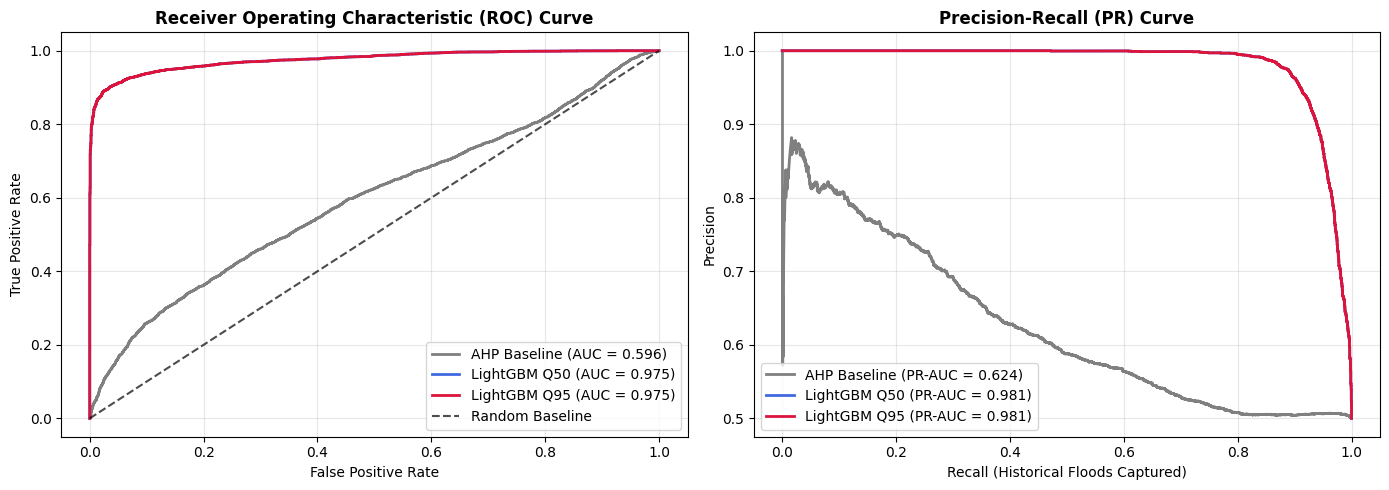

In [ ]:
# ==============================================================================
# PRODUCTION ENGINE: PHASE 7 — FINAL HISTORICAL VALIDATION & DISCRIMINATION METRICS
# ENVIRONMENT: Python 3.x (Validation & Diagnostics Stack)
# PURPOSE: Cross-evaluate Spatial Risk Scores against Historical Ground Truth
# ==============================================================================



print("\n" + "="*78)
print(" PRODUCTION ENGINE: PHASE 7 — HISTORICAL VALIDATION & METRICS")
print("="*78)

# ------------------------------------------------------------------------------
# STEP 1: WORKSPACE SANITY CHECKS
# ------------------------------------------------------------------------------
required_cols = [
    "Historical_Flood_Occurred",
    "FSI_Baseline",
    "Predicted_FSI_Median",
    "Predicted_FSI_Tail_Extreme"
]

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise KeyError(f"❌ Execution Halted: Missing required columns in master df: {missing_cols}")

# Isolate clean ground truth target and risk vectors
y_true = df["Historical_Flood_Occurred"].astype(int)
fsi_base = df["FSI_Baseline"]
pred_q50 = df["Predicted_FSI_Median"]
pred_q95 = df["Predicted_FSI_Tail_Extreme"]

print(f" ✅ Workspace Validated: Evaluating {len(df)} points against historical ground truth.")
print(f"   -> Total Historical Floods Recorded : {y_true.sum()} ({y_true.mean()*100:.2f}% base rate)")

# ------------------------------------------------------------------------------
# STEP 2: DISCRIMINATION METRICS ENGINE
# ------------------------------------------------------------------------------
def evaluate_risk_vector(y_true, y_pred, model_name):
    auc = roc_auc_score(y_true, y_pred)
    pr_auc = average_precision_score(y_true, y_pred)
    brier = brier_score_loss(y_true, y_pred)

    # Calculate separation delta between flooded and non-flooded spatial points
    mean_flooded = y_pred[y_true == 1].mean()
    mean_unflooded = y_pred[y_true == 0].mean()
    separation = mean_flooded - mean_unflooded

    return {
        "Model / Vector": model_name,
        "ROC-AUC": auc,
        "PR-AUC": pr_auc,
        "Brier Score": brier,
        "Mean Risk (Flooded)": mean_flooded,
        "Mean Risk (Unflooded)": mean_unflooded,
        "Separation Delta": separation
    }

metrics_list = [
    evaluate_risk_vector(y_true, fsi_base, "AHP Baseline"),
    evaluate_risk_vector(y_true, pred_q50, "LightGBM Median (Q50)"),
    evaluate_risk_vector(y_true, pred_q95, "LightGBM Extreme Tail (Q95)")
]

metrics_df = pd.DataFrame(metrics_list).set_index("Model / Vector")

print("\n--- GLOBAL HISTORICAL VALIDATION PERFORMANCE TABLE ---")
print(metrics_df.to_string(formatters={
    "ROC-AUC": "{:.4f}".format,
    "PR-AUC": "{:.4f}".format,
    "Brier Score": "{:.4f}".format,
    "Mean Risk (Flooded)": "{:.4f}".format,
    "Mean Risk (Unflooded)": "{:.4f}".format,
    "Separation Delta": "{:.4f}".format
}))
print("-" * 78)

# ------------------------------------------------------------------------------
# STEP 3: ACTUARIAL TAIL CAPTURE RATE (Q95 TOP TIER EVALUATION)
# ------------------------------------------------------------------------------
# Check what percentage of actual historic floods fall into the model's top 10% highest risk zone
top_10_threshold = pred_q95.quantile(0.90)
high_risk_points = pred_q95 >= top_10_threshold

total_floods = y_true.sum()
captured_floods = y_true[high_risk_points].sum()
capture_rate = (captured_floods / total_floods) * 100 if total_floods > 0 else 0.0

print(f"\n[ACTUARIAL TAIL CAPTURE ANALYSIS]:")
print(f"   -> Extreme Tail (Q95) Top 10% Risk Cutoff Threshold: {top_10_threshold:.4f}")
print(f"   -> Historic Flood Events Captured in Top 10% Zone   : {captured_floods} / {total_floods} ({capture_rate:.2f}%)")

# ------------------------------------------------------------------------------
# STEP 4: VISUAL DIAGNOSTIC CURVES (ROC & PRECISION-RECALL)
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot ROC Curves
vectors = [fsi_base, pred_q50, pred_q95]
labels = ["AHP Baseline", "LightGBM Q50", "LightGBM Q95"]
colors = ["gray", "royalblue", "crimson"]

for vec, lbl, col in zip(vectors, labels, colors):
    fpr, tpr, _ = roc_curve(y_true, vec)
    auc_val = roc_auc_score(y_true, vec)
    axes[0].plot(fpr, tpr, label=f"{lbl} (AUC = {auc_val:.3f})", color=col, linewidth=2)

axes[0].plot([0, 1], [0, 1], "k--", label="Random Baseline", alpha=0.7)
axes[0].set_title("Receiver Operating Characteristic (ROC) Curve", fontsize=12, fontweight='bold')
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# Plot Precision-Recall Curves
for vec, lbl, col in zip(vectors, labels, colors):
    precision, recall, _ = precision_recall_curve(y_true, vec)
    pr_auc_val = average_precision_score(y_true, vec)
    axes[1].plot(recall, precision, label=f"{lbl} (PR-AUC = {pr_auc_val:.3f})", color=col, linewidth=2)

axes[1].set_title("Precision-Recall (PR) Curve", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Recall (Historical Floods Captured)")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("="*78 + "\n")